In [1]:
import torch
import torch.nn as nn
import torch.optim as optim 
import torch.nn.functional as F
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
import tifffile

from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd

from typing import Optional, List, Callable

import os
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
class Road_Dataset(Dataset):
    def __init__(
            self,
            root: str,
            split: str,
            binarize_mask: bool = True,
            transforms: Optional[A.Compose] = None
    ):
        super().__init__()
        self.root = Path(root)
        self.split = split
        self.binarize_mask = binarize_mask
        self.transforms = transforms

        self.images_dir = self.root / split
        self.mask_dir = self.root / f"{split}_labels"

        images_paths = sorted(self.images_dir.glob("*.tiff"))
        self.images_paths = []
        self.mask_map = {}

        for img_path in images_paths:
            mask_path = self.mask_dir / f"{img_path.stem}.tif"
            if mask_path.exists():

                img = tifffile.imread(img_path)

                white_ratio = np.mean(np.all(img[..., :3] == 255, axis= -1))

                if white_ratio < 0.2: 
                    self.images_paths.append(img_path)
                    self.mask_map[img_path.stem] = mask_path
        print(f"Осталось: {len(self.images_paths)} из {len(images_paths)}\n")

    def __len__(self) -> int:
        return len(self.images_paths)
    
    def __getitem__(self, index : int):
        img_path = self.images_paths[index]
        mask_path = self.mask_map[img_path.stem]
        
        image = tifffile.imread(img_path)
        mask = tifffile.imread(mask_path)

        if self.binarize_mask:
            if mask.ndim == 3:
                mask = mask[..., 0]
            mask = (mask > 0).astype(np.float32)

        if self.transforms:
            augmented = self.transforms(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
            if mask.ndim == 2:
                mask = mask.unsqueeze(0)
        
        return image, mask

In [3]:
data_path = "archive/tiff"

train_transform = A.Compose([
    A.RandomCrop(height=512, width= 512),
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

train_dataset = Road_Dataset(root=data_path, split="train", transforms=train_transform)
val_dataset = Road_Dataset(root=data_path, split="val", transforms=val_transform)
test_dataset = Road_Dataset(root=data_path, split="test", transforms= val_transform)

print(f"train dataset len:{len(train_dataset)}")
print(f"val dataset len:{len(val_dataset)}")
print(f"test dataset len:{len(test_dataset)}")

Осталось: 841 из 1108

Осталось: 14 из 14

Осталось: 49 из 49

train dataset len:841
val dataset len:14
test dataset len:49


не использовать черные области с датасета

In [4]:
train_loader = DataLoader(train_dataset, batch_size= 8, shuffle= True, pin_memory= True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle= False, pin_memory= True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle= False, pin_memory= True)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4308496].


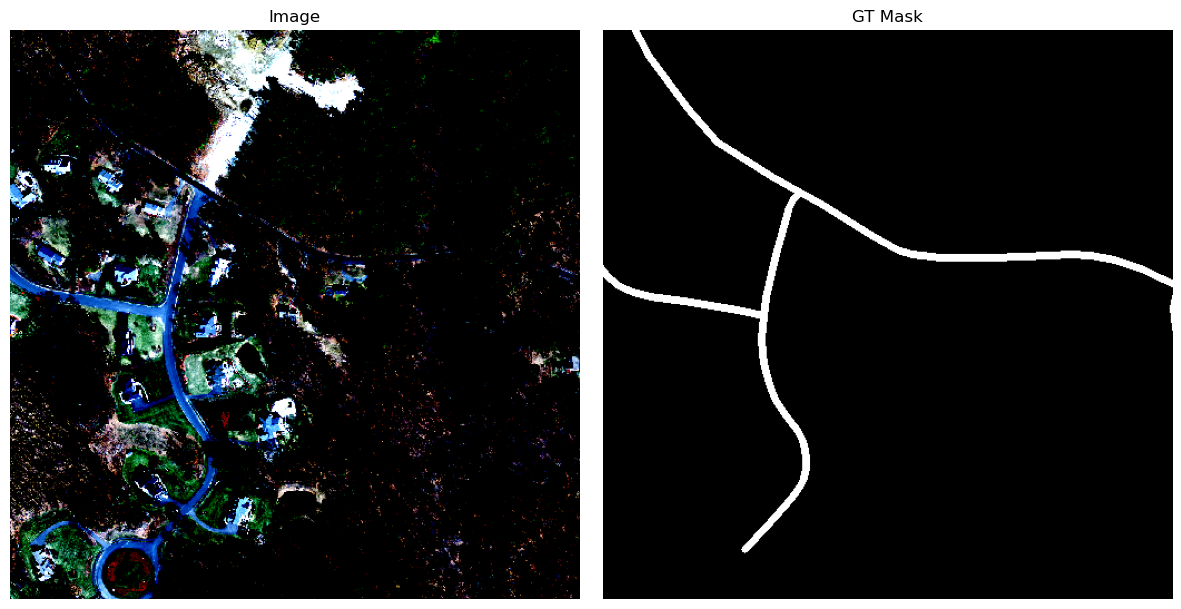

Image shape: torch.Size([3, 512, 512])
Mask shape: torch.Size([1, 512, 512])


In [5]:
images, masks = next(iter(train_loader))
image, mask = images[0], masks[0]


image_vis = image.permute(1, 2, 0).cpu().numpy()
mask_vis = mask.squeeze(0).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image_vis)
axes[0].set_title("Image")
axes[0].axis("off")

axes[1].imshow(mask_vis, cmap="gray")
axes[1].set_title("GT Mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Image shape:", image.shape if hasattr(image, "shape") else type(image))
print("Mask shape:", mask.shape if hasattr(mask, "shape") else type(mask))

In [6]:
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()

        self.upconv = nn.ConvTranspose2d(
            in_channels, in_channels // 2, kernel_size=2, stride=2
        )

        conv_in_channels = (in_channels // 2) + skip_channels
        
        self.conv_block = nn.Sequential(
            nn.Conv2d(conv_in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x, skip=None):
        x = self.upconv(x)

        if skip is not None:
            x = torch.cat([skip, x], dim=1)
        x = self.conv_block(x)
        return x

class ResNet18_UNet_ConvTranspose(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()

        encoder = torchvision.models.resnet18(weights='IMAGENET1K_V1')
        
        self.enc1 = nn.Sequential(encoder.conv1, encoder.bn1, encoder.relu) # [64, H/2, W/2]
        self.enc2 = nn.Sequential(encoder.maxpool, encoder.layer1)          # [64, H/4, W/4]
        self.enc3 = encoder.layer2                                          # [128, H/8, W/8]
        self.enc4 = encoder.layer3                                          # [256, H/16, W/16]
        self.enc5 = encoder.layer4                                          # [512, H/32, W/32]
        
        self.dec5 = DecoderBlock(512, 256, 256)
        self.dec4 = DecoderBlock(256, 128, 128)
        self.dec3 = DecoderBlock(128, 64, 64)
        self.dec2 = DecoderBlock(64, 64, 64)
        
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        
        self.final_conv = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        f1 = self.enc1(x)
        f2 = self.enc2(f1)
        f3 = self.enc3(f2)
        f4 = self.enc4(f3)
        bottom = self.enc5(f4)
        
        d5 = self.dec5(bottom, f4)
        d4 = self.dec4(d5, f3)
        d3 = self.dec3(d4, f2)
        d2 = self.dec2(d3, f1)
        d1 = self.dec1(d2)
    
        out = self.final_conv(d1)
        return out

In [ ]:
model = ResNet18_UNet_ConvTranspose(num_classes=1).to(device)

criterion = smp.losses.DiceLoss(mode='binary')
optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor= 0.1, patience= 3)
SAVE_DIR = "checkpoints"
EPOCH_SAVE_DIR = "running_results"
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(EPOCH_SAVE_DIR, exist_ok= True)

In [8]:
def get_metrics(outputs, masks, threshold = 0.5):
    probs = torch.sigmoid(outputs)
    preds = (probs > threshold).float()

    preds = preds.view(-1)
    masks = masks.view(-1)

    intersection = (preds * masks).sum()
    total = preds.sum() + masks.sum()
    union = total - intersection

    smooth = 1e-6

    IoU = (intersection + smooth) / (union + smooth)

    f1 = (2. * intersection + smooth) / (total + smooth)
    
    return IoU.item(), f1.item()

In [9]:
def sliding_window(model, image, patch_size = 512, stride = 256):
    B, C, H, W = image.shape

    preds = torch.zeros((B, 1, H, W), device= image.device)
    counts = torch.zeros((B, 1, H, W), device= image.device)

    for y in range(0, H, stride):
        for x in range(0, W, stride):
            x1 = min(x, max(0, W - patch_size))
            y1 = min(y, max(0, H - patch_size))
            x2 = min(x1 + patch_size, W)
            y2 = min(y1 + patch_size, H)

            patch = image[:, :, y1:y2, x1:x2]

            pad_h = patch_size - patch.shape[2]
            pad_w = patch_size - patch.shape[3]

            if pad_h > 0 or pad_w > 0:
                patch = F.pad(patch, (0, pad_w, 0, pad_h))

            logits = model(patch)
            
            if pad_h > 0 or pad_w > 0:
                logits = logits[:, :, :patch.shape[2], :patch.shape[3]]

            preds [:, :, y1:y2, x1:x2] += logits
            counts [:, :, y1:y2, x1:x2] += 1

    output = preds / torch.clamp(counts, min=1)
    return output

def train_epoch(model, loader, optimizer, criterion, device = device):
    model.train()
    running_loss = 0.0

    pbar = tqdm(loader, desc= "Training")
    for images, masks in pbar:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix({"loss":loss.item()})
    
    return running_loss / len(loader)

@torch.no_grad()
def validate(model, loader, criterion, device = device):
    model.eval()
    running_loss = 0.0 
    running_iou = 0.0
    running_f1 = 0.0

    pbar = tqdm(loader, desc= "Validation", leave=False)
    for images, masks in pbar:
        images = images.to(device)
        masks = masks.to(device)

        logits = sliding_window(model, images, patch_size=  512, stride= 256)
        loss = criterion(logits, masks)

        running_loss += loss.item()

        iou, f1 = get_metrics(logits, masks)

        running_iou += iou
        running_f1 += f1
    
    
    return running_loss / len(loader), running_iou / len(loader), running_f1 / len(loader)

для воспроизводимости - Cuda determenistic

In [ ]:
EPOCHS = 67
best_iou = 0.0
checkpoint_every = 3

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss = train_epoch(model, train_loader, optimizer, criterion)

    val_loss, val_iou, val_f1 = validate(model, val_loader, criterion)

    print(f"Train loss: {train_loss:.4f} | Val_loss: {val_loss:.4f}\n")
    print(f"Val IoU: {val_iou:.4f} | Val F1: {val_f1:.4f}")

    scheduler.step(val_iou)

    if val_iou > best_iou: 
        best_iou = val_iou
        checkpoint = {
            'epoch' : epoch,
            'model_state_dict' : model.state_dict(),
            'optimizer_state_dict' : optimizer.state_dict(),
            'scheduler_state_dict' : scheduler.state_dict(),
            'val_IoU' : val_iou,
            'rng_state' : torch.get_rng_state(),
            'cuda_rng_state' : torch.cuda.get_rng_state_all()
        }
        torch.save(checkpoint, f"{SAVE_DIR}/best_unet_IoU_{best_iou}.pth")
        print(">>> Best model saved! <<<")

    if (epoch + 1) % checkpoint_every == 0:
        checkpoint = {
            'epoch' : epoch,
            'model_state_dict' : model.state_dict(),
            'optimizer_state_dict' : optimizer.state_dict(),
            'scheduler_state_dict' : scheduler.state_dict(),
            'val_IoU' : val_iou,
            'rng_state' : torch.get_rng_state(),
            'cuda_rng_state' : torch.cuda.get_rng_state_all()
        }
        torch.save(checkpoint, f"{EPOCH_SAVE_DIR}/checkpoint_{epoch+1}.pth")


Epoch 1/67


Training: 100%|██████████| 111/111 [00:29<00:00,  3.71it/s, loss=0.667]


Train loss: 0.8188 | Val_loss: 0.7247

Val IoU: 0.4340 | Val F1: 0.6053
>>> Best model saved! <<<

Epoch 2/67


Training: 100%|██████████| 111/111 [00:29<00:00,  3.78it/s, loss=0.777]


Train loss: 0.7747 | Val_loss: 0.7047

Val IoU: 0.3576 | Val F1: 0.5267

Epoch 3/67


...

Train loss: 0.3066 | Val_loss: 0.2718

Val IoU: 0.6191 | Val F1: 0.7645

Epoch 66/67


Training: 100%|██████████| 111/111 [00:28<00:00,  3.83it/s, loss=0.319]


Train loss: 0.3072 | Val_loss: 0.2711

Val IoU: 0.6192 | Val F1: 0.7646

Epoch 67/67


Training: 100%|██████████| 111/111 [00:29<00:00,  3.74it/s, loss=0.284]
                                                         

Train loss: 0.2998 | Val_loss: 0.2709

Val IoU: 0.6196 | Val F1: 0.7649


доучить модель + домен поправить
сохранять сиды торча и лоадеров

Веса загружены из файла: checkpoints/best_unet_IoU_0.6206176728010178.pth


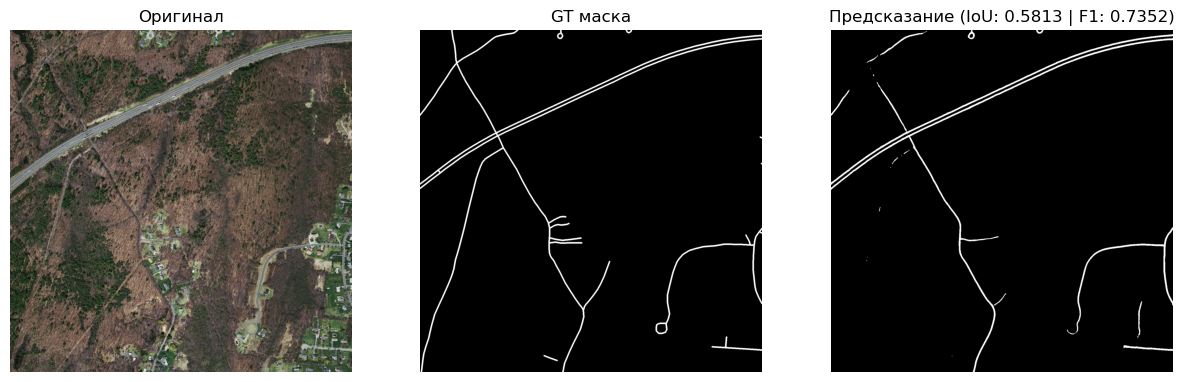

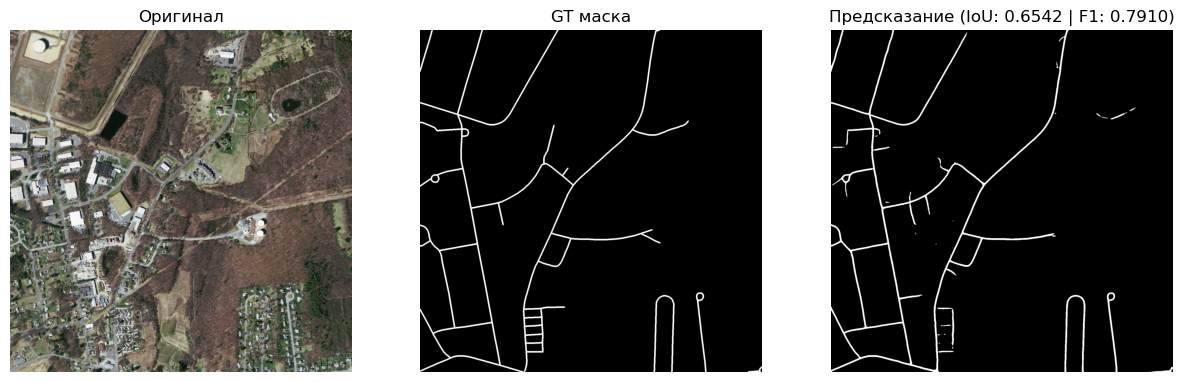

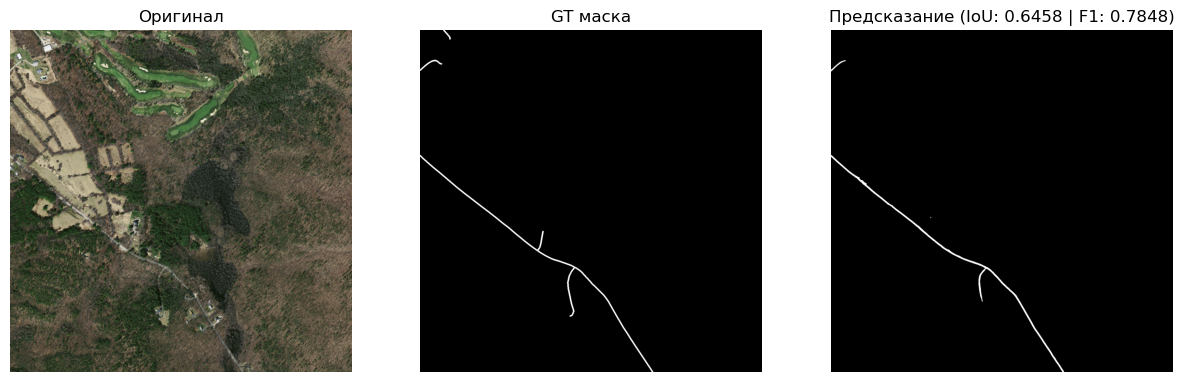

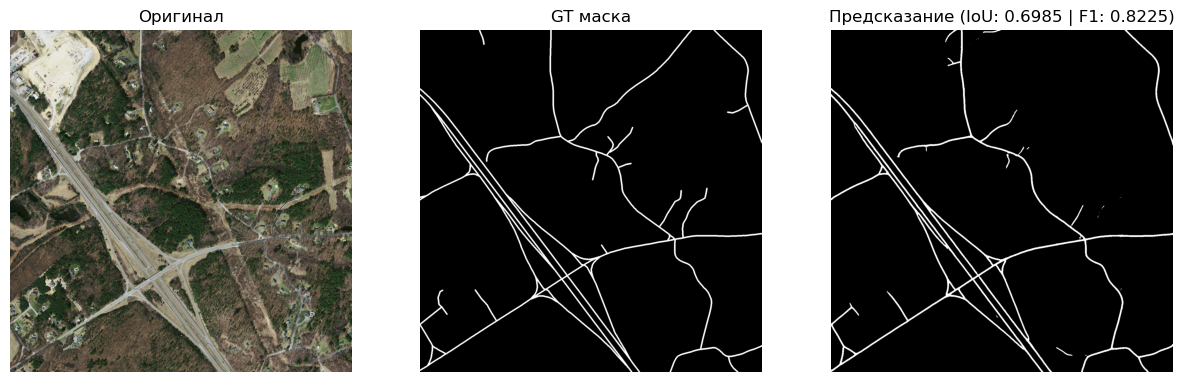

------------------------------
Avg IoU Score на тесте: 0.6406
Avg F1 (Dice) Score на тесте: 0.7802


In [11]:
import os
import glob
import matplotlib.pyplot as plt
import torch
import numpy as np

model_paths = glob.glob("checkpoints/best_unet_IoU_*.pth")
if model_paths:

    best_model_path = max(model_paths, key=os.path.getmtime)
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    print(f"Веса загружены из файла: {best_model_path}")
else:
    print("Сохраненные веса не найдены! Используются текущие веса модели.")

model.eval()
test_f1 = 0.0
test_iou = 0.0
num_samples = 0

patch_size = 512
stride = 256

with torch.no_grad():
    for i, (images, masks) in enumerate(test_loader):
        images = images.to(device)
        masks = masks.to(device)

        logits = sliding_window(model, images, patch_size=patch_size, stride=stride)
        
        iou, f1 = get_metrics(logits, masks)
        
        test_iou += iou
        test_f1 += f1
        num_samples += 1

        if i in range(0, 4):
            
            img_vis = images[0].permute(1, 2, 0).cpu().numpy()
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img_vis = std * img_vis + mean
            img_vis = np.clip(img_vis, 0, 1)

            gt_vis = masks[0].squeeze().cpu().numpy()

            probs = torch.sigmoid(logits[0])
            pred_vis = (probs.squeeze() > 0.5).cpu().numpy()
            
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            axes[0].imshow(img_vis)
            axes[0].set_title("Оригинал")
            axes[0].axis("off")

            axes[1].imshow(gt_vis, cmap="gray")
            axes[1].set_title("GT маска")
            axes[1].axis("off")

            axes[2].imshow(pred_vis, cmap="gray")
            axes[2].set_title(f"Предсказание (IoU: {iou:.4f} | F1: {f1:.4f})")
            axes[2].axis("off")
            plt.show()

avg_test_iou = test_iou / max(1, num_samples)
avg_test_f1 = test_f1 / max(1, num_samples)

print('-'*30)
print(f'Avg IoU Score на тесте: {avg_test_iou:.4f}')
print(f'Avg F1 (Dice) Score на тесте: {avg_test_f1:.4f}')

In [12]:
# from torchview import draw_graph
# import graphviz



# model_graph = draw_graph(
#     model, 
#     input_size=(1, 3, 512, 512), 
#     expand_nested=True, 
#     depth=3, 
#     device=device,
#     save_graph=True,
#     filename="unet_architecture",
#     directory="./"
# )


# print(f"Граф сохранен как unet_architecture.png.pdf")
# model_graph.visual_graph

In [13]:

def print_gpu_memory():
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**2
        reserved = torch.cuda.memory_reserved() / 1024**2
        print(f"--- GPU Memory Info ---")
        print(f"Allocated: {allocated:.2f} MiB") 
        print(f"Reserved:  {reserved:.2f} MiB")  
        print(f"-----------------------")
    else:
        print("CUDA не доступна.")

print_gpu_memory()


try:
    from torchinfo import summary
    model_stats = summary(model, input_size=(8, 3, 512, 512), device=device)
    print(model_stats)
except ImportError:
    print("\nДля детальной таблицы установите: !pip install torchinfo")

--- GPU Memory Info ---
Allocated: 276.85 MiB
Reserved:  4426.00 MiB
-----------------------
Layer (type:depth-idx)                   Output Shape              Param #
ResNet18_UNet_ConvTranspose              [8, 1, 512, 512]          --
├─Sequential: 1-1                        [8, 64, 256, 256]         --
│    └─Conv2d: 2-1                       [8, 64, 256, 256]         9,408
│    └─BatchNorm2d: 2-2                  [8, 64, 256, 256]         128
│    └─ReLU: 2-3                         [8, 64, 256, 256]         --
├─Sequential: 1-2                        [8, 64, 128, 128]         --
│    └─MaxPool2d: 2-4                    [8, 64, 128, 128]         --
│    └─Sequential: 2-5                   [8, 64, 128, 128]         --
│    │    └─BasicBlock: 3-1              [8, 64, 128, 128]         73,984
│    │    └─BasicBlock: 3-2              [8, 64, 128, 128]         73,984
├─Sequential: 1-3                        [8, 128, 64, 64]          --
│    └─BasicBlock: 2-6                   [8, 128, 